In [43]:
from dotenv import load_dotenv

load_dotenv()

True

In [44]:
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

try:
    llm = ChatOpenAI(
        model="gpt-4o"
    )
    llm_response = llm.invoke("What is the capital of France?")
except:
    llm = ChatGroq(
        model="deepseek-r1-distill-llama-70b"
    )
    llm_response = llm.invoke("What is the capital of France?")


print(llm_response.content)

<think>

</think>

The capital of France is Paris.


In [45]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

@tool
def search(query: str) -> TavilySearchResults:
    """Search the web for a given query."""
    tavily = TavilySearchResults()
    result = tavily.invoke({"query": query})
    return f"Result for '{query}': \n {result}"

search_response = search.invoke("What is the capital of France?")
print(search_response)

Result for 'What is the capital of France?': 
 [{'title': 'Paris facts: the capital of France in history', 'url': 'https://home.adelphi.edu/~ca19535/page%204.html', 'content': 'page 4\n\n===============\n\nHomeSpainSydneySan FranciscoParisLas VegasMaui\n\n Paris, France\n\nImage 1\n\nParis facts: Paris, the capital of France\n---------------------------------------------\n\nParis is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants).\n\nParis has 2.234 million inhabitants end 2011. She is the core of Ile de France region (12 million people). [...] Before Paris, the capital of France was Lyon (under the Romans). Paris first became the capital of France in 508 under King Clovis. After centuries with no unique capital of France, Paris retrieved its status of capital of France under King Philippe Auguste, who reigned between 1180 and 1223. You can see remains of the Philippe August Paris walls in the passageway between the Louvre parking and Lou

In [46]:
@tool
def multiplier(x: int, y: int) -> int:
    """Multiply two numbers."""
    return x * y

multiplier_response = multiplier.invoke({"x": 3, "y": 4})
print(multiplier_response)

12


In [47]:
tools = [search, multiplier]
llm_with_tools = llm.bind_tools(tools)

In [48]:
result = llm_with_tools.invoke("Whats the gdp of india?")

In [49]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'sav2ek3ep', 'function': {'arguments': '{"query":"GDP of India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 170, 'total_tokens': 274, 'completion_time': 0.421307484, 'prompt_time': 0.010671079, 'queue_time': 0.053327152, 'total_time': 0.431978563}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d256918f-0b30-4804-8667-09ba3fff3983-0', tool_calls=[{'name': 'search', 'args': {'query': 'GDP of India'}, 'id': 'sav2ek3ep', 'type': 'tool_call'}], usage_metadata={'input_tokens': 170, 'output_tokens': 104, 'total_tokens': 274})

In [50]:
result.tool_calls

[{'name': 'search',
  'args': {'query': 'GDP of India'},
  'id': 'sav2ek3ep',
  'type': 'tool_call'}]

In [51]:
tool_mapping = {tool.name: tool for tool in tools}

In [52]:
tool_mapping

{'search': StructuredTool(name='search', description='Search the web for a given query.', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x122c07e20>),
 'multiplier': StructuredTool(name='multiplier', description='Multiply two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiplier'>, func=<function multiplier at 0x122c07760>)}

In [53]:
tool_mapping[result.tool_calls[0]["name"]].invoke(result.tool_calls[0]["args"])

'Result for \'GDP of India\': \n [{\'title\': \'India GDP - Worldometer\', \'url\': \'https://www.worldometers.info/gdp/india-gdp/\', \'content\': \'Nominal (current) Gross Domestic Product (GDP) of India is $3,567,550,000,000 (USD) as of 2023.\\n   Real GDP (constant, inflation adjusted) of India reached $3,215,970,000,000 in 2023.\\n   GDP Growth Rate in 2023 was 8.15%, representing a change of 242,430,000,000 US$ over 2022, when Real GDP was $2,973,540,000,000. [...] GDP per Capita in India (with a population of 1,438,069,596 people) was $2,236 in 2023, an increase of $150 from $2,086 in 2022; this represents a change of 7.2% in GDP per capita. [...] Image 2 India GDP\\n==================================================================================\\n\\nGDP nominal (2023)\\n\\n$3,567,550,000,000\\n\\nGDP growth rate\\n\\n(2023)\\n\\n 8.15% Image 3\\n\\n (Current US Dollars). _Sources include: World Bank, United Nations._\', \'score\': 0.9437689}, {\'title\': \'India GDP - Trading

In [54]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import HumanMessage, BaseMessage

In [55]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [56]:
def invoke_model(state: AgentState):
    messages = state["messages"]
    question = messages[-1]
    response = llm_with_tools.invoke(question)
    return {"messages": [response]}

In [57]:
def router(state: AgentState):
    tool_calls = state["messages"][-1].tool_calls
    if tool_calls:
        return "tool"
    else:
        return "end"

In [58]:
def invoke_tool(state: AgentState):
    tool_details = state["messages"][-1].tool_calls
    if tool_details is None:
        return Exception("No tool calls found in the last message.")
    print(f"Selected tool: {tool_details[0]['name']}")
    
    if tool_details[0]["name"] == "search":
        response=input(prompt=f"[yes/no] Do you want to continue with this expensive web search?")
        if response.lower() == "no":
            print("web seach discarded by the user. Exiting gracefully.")
            raise Exception("Web search discarded by the user.")
            
    
    response = tool_mapping[tool_details[0]["name"]].invoke(tool_details[0]["args"])
    return {"messages": [response]}

In [59]:
from langgraph.graph import StateGraph, START, END

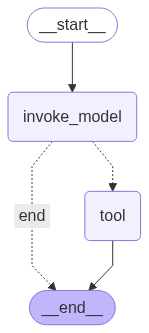

In [60]:
graph = StateGraph(AgentState)
graph.add_node("invoke_model", invoke_model)
graph.add_node("tool", invoke_tool)

graph.add_conditional_edges(
    "invoke_model",
    router,
    {
        "tool": "tool",
        "end": END
    }
)

graph.add_edge("tool", END)
graph.set_entry_point("invoke_model")

app = graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [61]:
app.invoke({"messages": ["What is the gdp of india?"]})

Selected tool: search


{'messages': ['What is the gdp of india?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wa49kk49y', 'function': {'arguments': '{"query":"GDP of India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 161, 'prompt_tokens': 171, 'total_tokens': 332, 'completion_time': 0.783370709, 'prompt_time': 0.010785187, 'queue_time': 0.053935593000000004, 'total_time': 0.794155896}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--bd648eaa-cfd3-4fbf-9424-fd024e78c695-0', tool_calls=[{'name': 'search', 'args': {'query': 'GDP of India'}, 'id': 'wa49kk49y', 'type': 'tool_call'}], usage_metadata={'input_tokens': 171, 'output_tokens': 161, 'total_tokens': 332}),
  'Result for \'GDP of India\': \n [{\'title\': \'India GDP - Worldometer\', \'url\': \'https://www.worldometers.info/gdp/india-gdp/\', \'content\': \'Nominal (current) Gross Dome

In [62]:
app.invoke({"messages": ["What is the multiplication of 5 and 20?"]})

Selected tool: multiplier


{'messages': ['What is the multiplication of 5 and 20?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'khwqqxbz2', 'function': {'arguments': '{"x":5,"y":20}', 'name': 'multiplier'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 236, 'prompt_tokens': 174, 'total_tokens': 410, 'completion_time': 0.929334201, 'prompt_time': 0.010914016, 'queue_time': 0.053581242, 'total_time': 0.940248217}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--4137eb7b-0348-4401-8887-70381e21d782-0', tool_calls=[{'name': 'multiplier', 'args': {'x': 5, 'y': 20}, 'id': 'khwqqxbz2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 174, 'output_tokens': 236, 'total_tokens': 410}),
  100]}

In [63]:
app.invoke({"messages": ["What is the gdp of india?"]})

Selected tool: search
web seach discarded by the user. Exiting gracefully.


Exception: Web search discarded by the user.

## IN-Built Human Loop Function

In [64]:
from typing import Annotated, Sequence, TypedDict
import operator
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    

In [71]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [65]:
tools

[StructuredTool(name='search', description='Search the web for a given query.', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x122c07e20>),
 StructuredTool(name='multiplier', description='Multiply two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiplier'>, func=<function multiplier at 0x122c07760>)]

In [66]:
llm_with_tools = llm.bind_tools(tools)

In [82]:
def ai_assistant(state: AgentState):
    message = state["messages"]
    return {"messages": [llm_with_tools.invoke(message)]}

In [83]:
from langgraph.prebuilt import ToolNode, tools_condition

In [84]:
tool_node = ToolNode(tools)

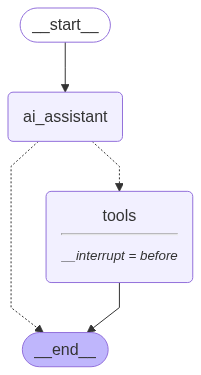

In [85]:
workflow = StateGraph(AgentState)

workflow.add_node("ai_assistant", ai_assistant)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "ai_assistant")
workflow.add_conditional_edges(
    "ai_assistant",
    tools_condition
)

workflow.add_edge("ai_assistant", "tools")


app = workflow.compile(checkpointer=memory, interrupt_before=["tools"])

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [116]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

In [117]:
from langchain_core.messages import HumanMessage, AIMessage

result = app.invoke({
    "messages": [
        HumanMessage(content="What is the current GDP of China?")
    ]
}, config=config)

In [118]:
snapshot = app.get_state(config)

In [119]:
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='What is the current GDP of China?', additional_kwargs={}, response_metadata={}), HumanMessage(content='What is the current GDP of China?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'd71heve2c', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 180, 'total_tokens': 248, 'completion_time': 0.256982605, 'prompt_time': 0.011224937, 'queue_time': 0.053282579999999996, 'total_time': 0.268207542}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c37da4d4-7aa9-4477-9063-4cf1ad1f52fd-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'd71heve2c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 180, 'output_token

In [120]:
snapshot.values["messages"][-1]

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '60ftqhfrf', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 431, 'prompt_tokens': 2481, 'total_tokens': 2912, 'completion_time': 2.066709911, 'prompt_time': 0.183311148, 'queue_time': 0.054532550999999985, 'total_time': 2.250021059}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--7b92932e-9405-432a-8503-5b457963dd3d-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': '60ftqhfrf', 'type': 'tool_call'}], usage_metadata={'input_tokens': 2481, 'output_tokens': 431, 'total_tokens': 2912})

In [121]:
if snapshot.values["messages"][-1].tool_calls[0]["name"] == "search":
    if input(prompt=f"[yes/no] Do you want to continue with this expensive web search?").lower() == "no":
        print("Web tool calls found in the last message.")
        raise Exception("Web search discarded by the user.")
    else:
        app.invoke(None, config=config)
else:
    app.invoke(None, config=config) # None means resume the last state or process

In [96]:
app.invoke(None, config=config)

{'messages': [HumanMessage(content='What is the current GDP of China?', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='What is the current GDP of China?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'd71heve2c', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 180, 'total_tokens': 248, 'completion_time': 0.256982605, 'prompt_time': 0.011224937, 'queue_time': 0.053282579999999996, 'total_time': 0.268207542}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c37da4d4-7aa9-4477-9063-4cf1ad1f52fd-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'd71heve2c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 180, 'output_tokens': 68, 'total_to

In [122]:
from langchain_core.messages import ToolMessage

In [125]:
result = app.invoke({
    "messages": [
        HumanMessage(content="What is the current GDP of Japan?")
    ]
}, config=config)

In [126]:
tool_call_id = app.get_state(config).values["messages"][-1].tool_calls[0]["id"]
tool_call_id

'ycby628yy'

In [127]:
new_tool_message = [
    ToolMessage(content="According to the latest data, the GDP of Japan is approximately 4.9 trillion USD.", tool_call_id=tool_call_id),
]

In [128]:
app.update_state(config=config, values={"messages": new_tool_message})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f059760-cc22-6298-801b-4d292d07cb22'}}

In [129]:
app.get_state(config).values["messages"][-1]

ToolMessage(content='According to the latest data, the GDP of Japan is approximately 4.9 trillion USD.', tool_call_id='ycby628yy')

In [130]:
app.invoke(None, config=config)

{'messages': [HumanMessage(content='What is the current GDP of China?', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='What is the current GDP of China?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'd71heve2c', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 180, 'total_tokens': 248, 'completion_time': 0.256982605, 'prompt_time': 0.011224937, 'queue_time': 0.053282579999999996, 'total_time': 0.268207542}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c37da4d4-7aa9-4477-9063-4cf1ad1f52fd-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'd71heve2c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 180, 'output_tokens': 68, 'total_to